In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report, roc_curve

In [2]:
df = pd.read_csv(r"C:\Users\shanz\Downloads\archive.csv\churn-bigml-20.csv")
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False


In [3]:
df = df.drop_duplicates()
df = df.dropna()

In [4]:
print(df.isnull().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


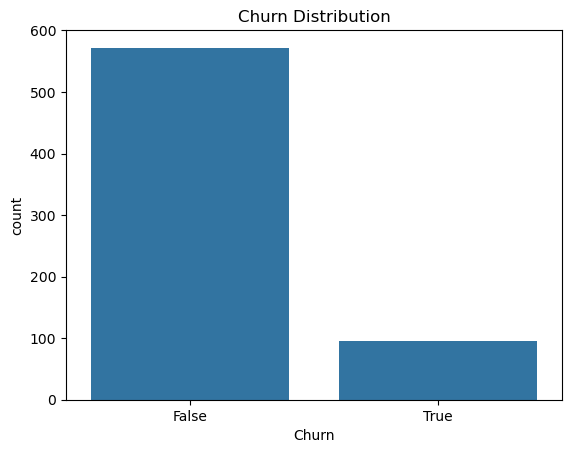

In [5]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

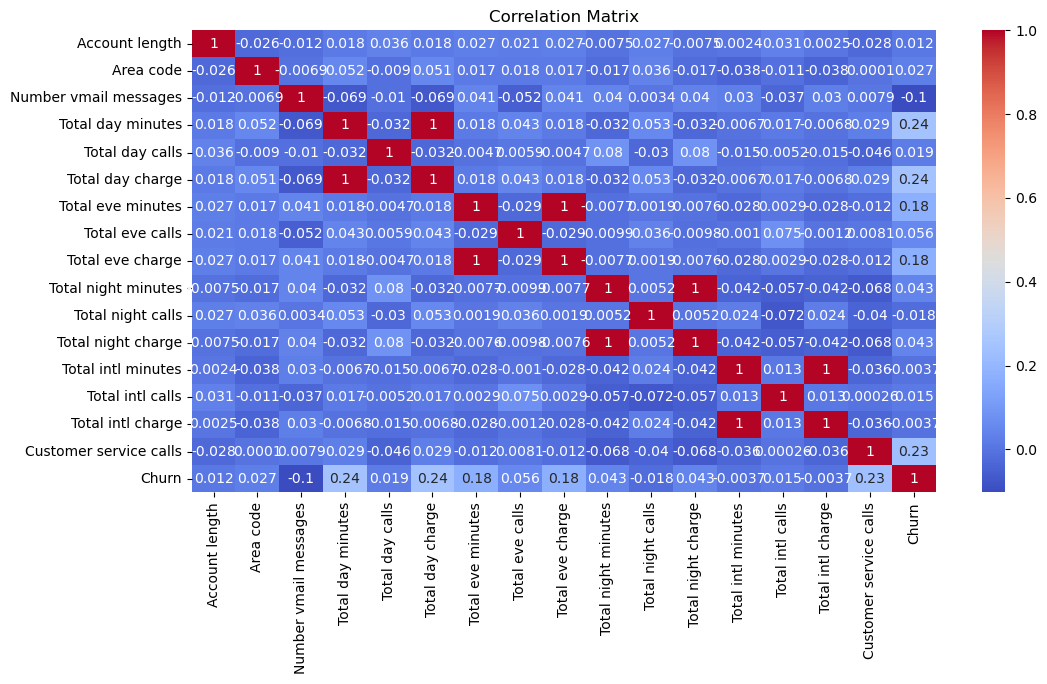

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


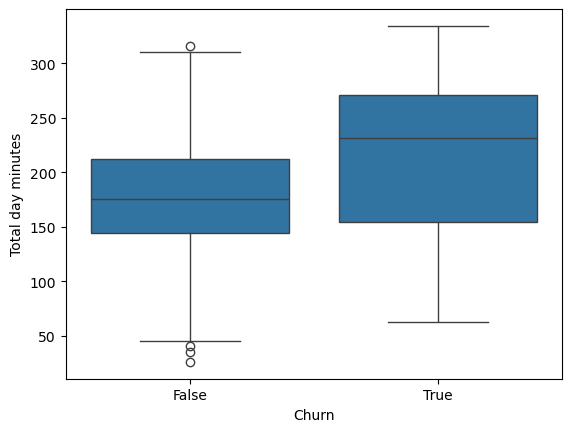

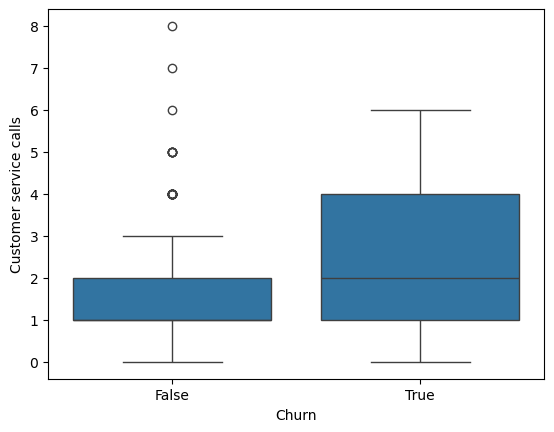

In [7]:
sns.boxplot(x='Churn', y='Total day minutes', data=df)
plt.show()

sns.boxplot(x='Churn', y='Customer service calls', data=df)
plt.show()

In [12]:
df['Churn'] = df['Churn'].astype(int)
df.drop(['State', 'Area code', 'International plan'], axis=1, inplace=True)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
print(df.columns)

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [15]:
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [16]:
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


--- Logistic Regression ---
Accuracy: 0.8656716417910447
Recall: 0.15789473684210525
ROC-AUC: 0.7935926773455378

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       115
           1       0.60      0.16      0.25        19

    accuracy                           0.87       134
   macro avg       0.74      0.57      0.59       134
weighted avg       0.84      0.87      0.83       134


--- Random Forest ---
Accuracy: 0.9104477611940298
Recall: 0.47368421052631576
ROC-AUC: 0.8839816933638442

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       115
           1       0.82      0.47      0.60        19

    accuracy                           0.91       134
   macro avg       0.87      0.73      0.77       134
weighted avg       0.90      0.91      0.90       134



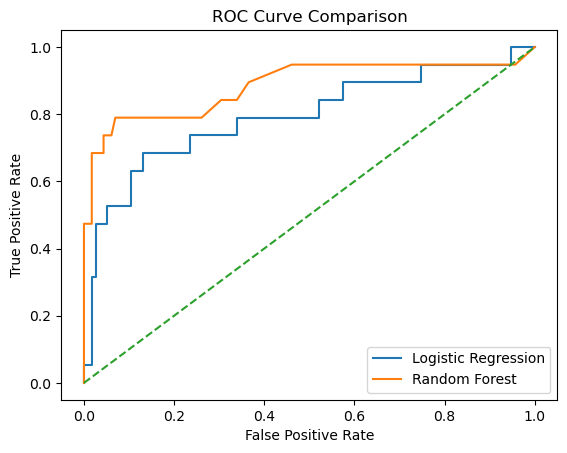

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [18]:
df['churn_probability'] = rf.predict_proba(scaler.transform(X))[:,1]


In [19]:
high_risk_customers = df[df['churn_probability'] > 0.7]

print(high_risk_customers.head())

    Account length  Voice mail plan  Number vmail messages  Total day minutes  \
1               65                0                      0              129.1   
2              161                0                      0              332.9   
7              119                0                      0              159.1   
16              77                0                      0              251.8   
35             208                0                      0              326.5   

    Total day calls  Total day charge  Total eve minutes  Total eve calls  \
1               137             21.95              228.5               83   
2                67             56.59              317.8               97   
7               114             27.05              231.3              117   
16               72             42.81              205.7              126   
35               67             55.51              176.3              113   

    Total eve charge  Total night minutes  Total n